In [50]:
import pickle as pkl
Model=pkl.dump(model,open("Model.pkl","wb"))

# scaling=pkl.dump(Normalization,open("normalization.pkl","wb"))

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,PowerTransformer
from sklearn.metrics import precision_score,accuracy_score,f1_score,confusion_matrix,classification_report,recall_score
import xgboost
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline


In [2]:
spam=pd.read_csv("spam_detection_dataset.csv")
spam=spam.drop(columns=['sender_score'])

In [6]:
spam

,num_links,num_words,has_offer,all_caps,is_spam
0,3,98,1,0,0
1,0,170,0,1,0
2,0,38,0,0,0
3,0,116,0,0,0
4,3,89,1,1,1
...,...,...,...,...,...
19995,1,22,1,0,0
19996,3,154,0,1,1
19997,4,109,0,1,0
19998,2,197,0,0,0


In [3]:
fewCols=["num_links","num_words"]

In [4]:
spam.describe()

,num_links,num_words,has_offer,all_caps,is_spam
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,1.497300,109.506150,0.302750,0.097800,0.09175
std,1.220478,51.969579,0.459459,0.297051,0.28868
min,0.000000,20.000000,0.000000,0.000000,0.00000
25%,1.000000,64.000000,0.000000,0.000000,0.00000
50%,1.000000,110.000000,0.000000,0.000000,0.00000
75%,2.000000,154.000000,1.000000,0.000000,0.00000
max,9.000000,199.000000,1.000000,1.000000,1.00000


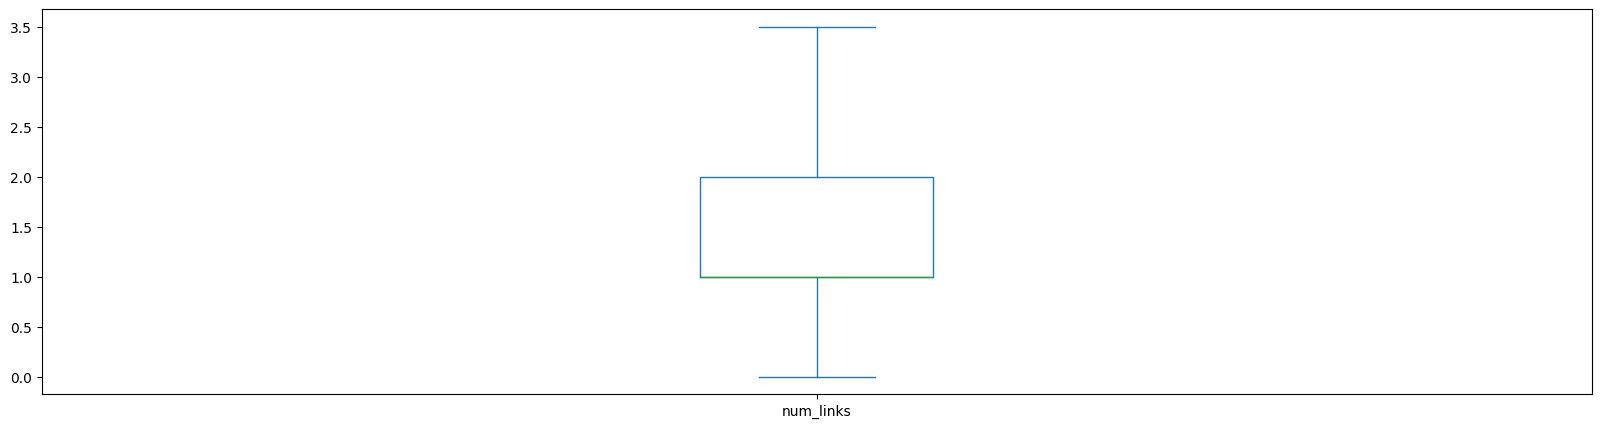

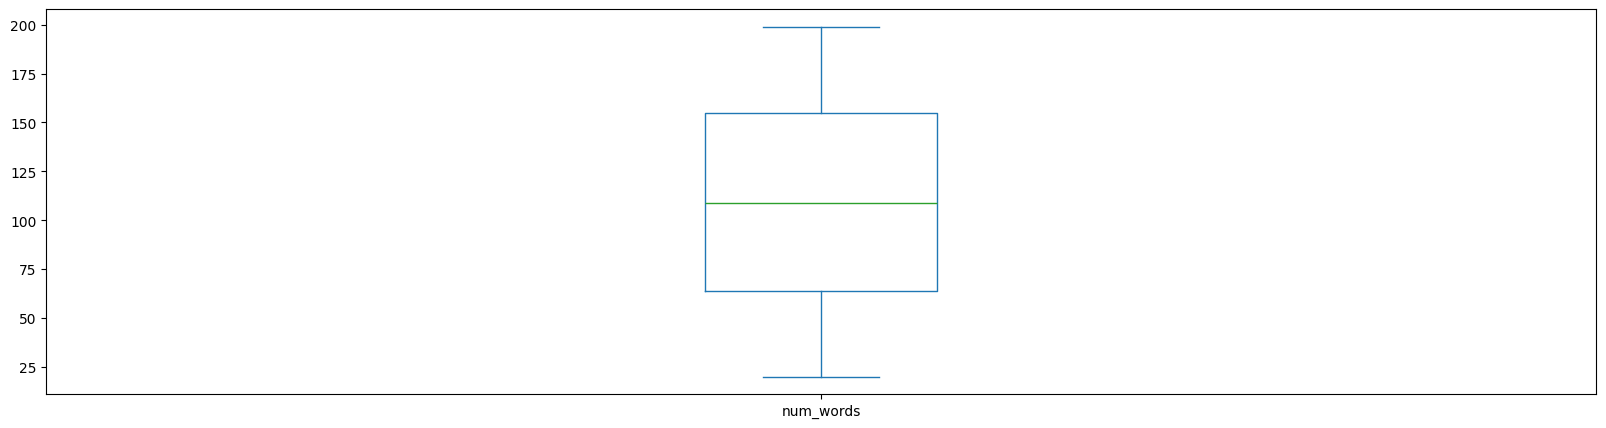

In [29]:
# check outliers
for cols in fewCols:
    plt.figure(figsize=(20,5))
    xTrain[cols].plot(kind="box")

In [7]:
# split data
x=spam.drop(columns=['is_spam'])
y=spam['is_spam']
xTrain,xTest,yTrain,yTest=train_test_split(x,y,random_state=34)

In [30]:
import pickle as pkl

bounds = {}
for colOut in fewCols:
    Q1    = xTrain[colOut].quantile(0.25)
    Q3    = xTrain[colOut].quantile(0.75)
    IQR   = Q3 - Q1
    Upper = Q3 + IQR * 1.5
    Lower = Q1 - IQR * 1.5       

    xTrain[colOut] = xTrain[colOut].clip(lower=Lower, upper=Upper)  
    xTest[colOut]  = xTest[colOut].clip(lower=Lower, upper=Upper)

    bounds[colOut] = {"lower": Lower, "upper": Upper}

pkl.dump(bounds, open("bounds.pkl", "wb"))                           

In [31]:
# skewness
for skew in fewCols:
    skew=xTrain[skew].skew()
    print(skew)
    

0.2984449796287446
0.0021255868235818347


In [32]:
# corr
# fewCols=["num_links","num_words"]
spam['num_words'].corr(spam['is_spam'])

np.float64(0.0016305175184767704)

In [35]:
# data splitting
x=spam.drop(columns=['is_spam'])
y=spam['is_spam']
xTrain,xTest,yTrain,yTest=train_test_split(x,y,test_size=0.3,random_state=34)

In [36]:
xTrain

,num_links,num_words,has_offer,all_caps
18584,2,21,1,0
10177,2,98,0,0
5761,0,105,1,1
5289,0,197,0,0
5013,0,114,0,0
...,...,...,...,...
16708,2,42,1,0
3157,0,177,1,0
10730,3,169,0,0
5242,0,174,1,1


In [39]:
spam["is_spam"].value_counts()

is_spam
0    18165
1     1835
Name: count, dtype: int64

In [42]:

# model
scale_pos_weight = 18165 / 1835

model=XGBClassifier(

n_estimators=490,
    learning_rate=0.01,
    reg_alpha=0.1,\
    scale_pos_weight =9.90,
    reg_lambda=0.1,
    random_state=42
)
model.fit(xTrain,yTrain)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [43]:
# prediction
prediction=model.predict(xTest)

In [44]:
xTest

,num_links,num_words,has_offer,all_caps
4012,3,181,1,0
11632,1,111,0,0
12407,1,134,0,0
11180,0,196,1,1
6301,0,151,1,0
...,...,...,...,...
8684,1,124,0,1
19682,3,120,0,0
16765,1,132,0,0
18753,3,104,1,0


In [45]:
# prediction
prediction=model.predict(xTest)

In [46]:
model.classes_

array([0, 1])

In [47]:
# Extract classification report
# report=classification_report(yTest,prediction,target_names=model.classes_,output_dict=True)

report=classification_report(yTest,prediction,target_names=model.classes_,output_dict=True)

In [48]:
# classification report
report

{np.int64(0): {'precision': 0.97820777756904,
  'recall': 0.955939049017808,
  'f1-score': 0.9669452181987,
  'support': 5447.0},
 np.int64(1): {'precision': 0.6454948301329394,
  'recall': 0.7902350813743219,
  'f1-score': 0.7105691056910569,
  'support': 553.0},
 'accuracy': 0.9406666666666667,
 'macro avg': {'precision': 0.8118513038509897,
  'recall': 0.8730870651960649,
  'f1-score': 0.8387571619448785,
  'support': 6000.0},
 'weighted avg': {'precision': 0.9475427342470129,
  'recall': 0.9406666666666667,
  'f1-score': 0.9433158864959124,
  'support': 6000.0}}

In [49]:
# turn classification report to df
reportDf=pd.DataFrame(report,columns=model.classes_).transpose()
reportDf

,precision,recall,f1-score,support
0,0.978208,0.955939,0.966945,5447.0
1,0.645495,0.790235,0.710569,553.0
